# Communication

Communication is the **C** of CNS (communication, navigation and surveillance). Once navigation has
produced a measurement, the communication layer decides whether that measurement reaches the other
aircraft, and how late. It models the *effect* of a datalink such as ADS-B or ADS-L — messages
lost, delayed, and arriving at irregular update intervals — not the message protocol itself.

The layer is a publish–subscribe system in all but name. An aircraft whose broadcast clock is due
publishes one measurement; the channel offers it to every other aircraft over an independent
directed link; each receiver keeps the latest message it actually got. Seven effects act on that
path, and this notebook covers all of them:

| Effect | Where it lives | Parameter | Unit |
|---|---|---|---|
| Broadcast interval | `BroadcastSchedule` | `interval` (or `at_rate`) | s (or Hz) |
| Off-phasing | `BroadcastSchedule` | `phase` | s |
| Jitter | `BroadcastSchedule` | `jitter` | s |
| Reception probability | `Comm` | `reception_prob` | probability |
| Latency | `Comm` | `latency` | s |
| Transmitter / receiver failure | `RadioHealth` | `tx_fail_rate`, `rx_fail_rate` | **per hour** |
| Surveillance range | `SurveillanceRange` | `max_range` | m |

The last section shows how to extend each of these: your own broadcast rate, latency model, link
gate, or a whole channel of your own.

In [1]:
%matplotlib inline
import math
from dataclasses import dataclass, replace

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import rng as rngtools
from opencdarr.cns import (
    CNS,
    CnsState,
    CnsStreams,
    Comm,
    CommState,
    GnssNavigation,
    LastKnown,
    LinkGate,
    Message,
    RadioHealth,
    RadioHealthState,
    SurveillanceRange,
    TransceiverComm,
    age,
    constant_latency,
    lognormal_latency,
    radio_health,
    uniform_latency,
)
from opencdarr import geo
from opencdarr.cns.base import CommunicationModel
from opencdarr.cns.broadcast import BroadcastSchedule
from opencdarr.state import AircraftState

BLUE, RED, ORANGE, PURPLE, GREY = "#1f77b4", "#d62728", "#ff7f0e", "#9467bd", "0.55"
INTERVAL = 1.0
IDS = ("OWN", "INT")


def aircraft(aid: str, gs: float = 10.0, pos_ci95: float = 0.0, vel_ci95: float = 0.0):
    """A minimal state; only the id and ground speed matter for these demonstrations."""
    return AircraftState(id=aid, lat=52.0, lon=4.0, trk=0.0, gs=gs,
                         pos_ci95=pos_ci95, vel_ci95=vel_ci95)


# `Comm.step` takes the roster as aircraft, not ids: a gate may read their geometry. Nothing
# in this notebook gates on range, so these are the same minimal co-located states.
ROSTER = tuple(aircraft(aid) for aid in IDS)
LINK_ROSTER = tuple(aircraft(aid) for aid in ("SRC", "RCV"))


def message(aid: str, t: float, gs: float = 10.0) -> Message:
    return Message(source=aid, state=aircraft(aid, gs=gs), t_meas=t)


def comm_rng(seed: int = 0):
    return rngtools.generator(rngtools.root_seed_sequence(seed))

## One broadcast tick

`CNS.sense` is the single call a runner makes. It runs the three layers in a fixed order —
navigation measures, communication delivers, surveillance reads — and returns the advanced state
plus what each aircraft now perceives. Everything else in this notebook is a variation on the
models handed to it.

`CnsState` is a frozen value threaded in and out, so nothing hides on the model object. That is
what lets a rare-event sampler clone a run mid-flight and have the clone see exactly what the
parent saw.

In [2]:
cns = CNS(communication=Comm(reception_prob=1.0, latency=0.0), surveillance=LastKnown())
state = cns.initial_state(2)
streams = CnsStreams(comm=comm_rng(0))

truth = [aircraft("OWN", gs=10.0), aircraft("INT", gs=25.0)]
state, perception = cns.sense(truth, firing=(0, 1), t=0.0, cns=state, streams=streams)

for i, aid in enumerate(IDS):
    seen = {ac.id: ac.gs for ac in perception[i].traffic}
    print(f"{aid}: own gs {perception[i].own.gs:5.1f} m/s   sees {seen}")

print("\ndelivered links (receiver <- source):", sorted(state.comm.held))

OWN: own gs  10.0 m/s   sees {'INT': 25.0}
INT: own gs  25.0 m/s   sees {'OWN': 10.0}

delivered links (receiver <- source): [('INT', 'OWN'), ('OWN', 'INT')]


## Broadcast timing

`BroadcastSchedule` owns *when* an aircraft transmits; the channel owns what happens to the message
afterwards. Three knobs:

- `interval` — the cadence in seconds. `BroadcastSchedule.at_rate(2.0)` is the same thing spelled
  in hertz.
- `phase` — a per-aircraft start offset. The default aligns every aircraft at `t = 0`, which is the
  pessimally correlated case: the whole fleet updates on the same tick. Real transmitters are not
  synchronised.
- `jitter` — a dither of `U(-j, +j)` added to every gap, the slot randomisation real ADS-B uses so
  transmitters do not collide systematically. The mean cadence is unchanged.

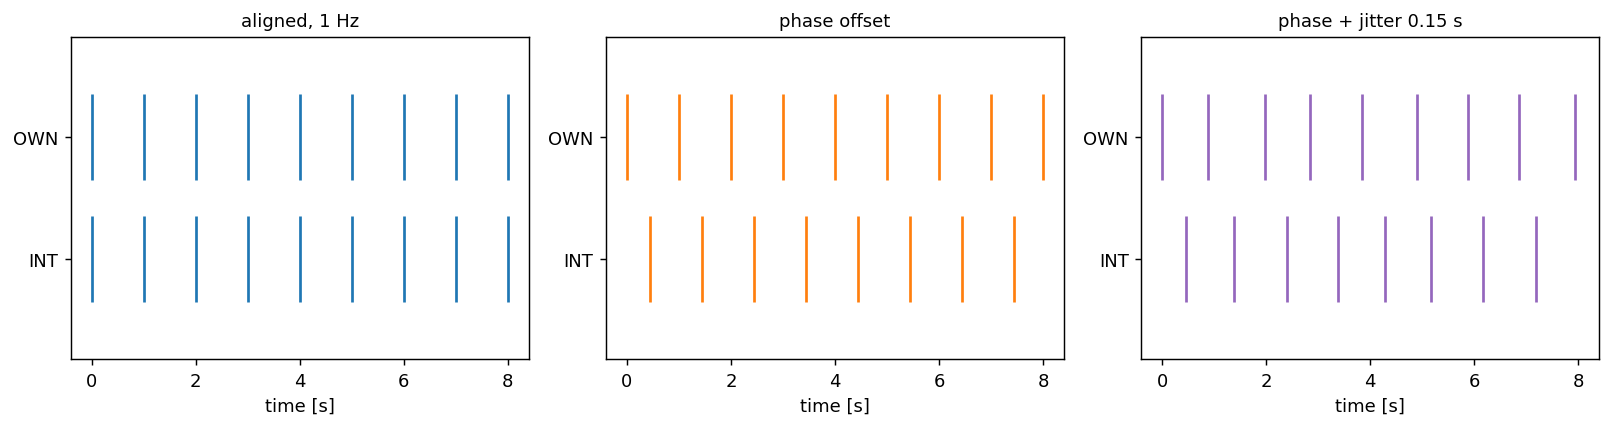

at_rate(2.0) -> interval 0.5 s


In [3]:
schedules = [
    ("aligned, 1 Hz", BroadcastSchedule(interval=INTERVAL), BLUE),
    ("phase offset", BroadcastSchedule(interval=INTERVAL, phase=[0.0, 0.45]), ORANGE),
    ("phase + jitter 0.15 s", BroadcastSchedule(interval=INTERVAL, phase=[0.0, 0.45], jitter=0.15),
     PURPLE),
]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4), sharex=True)
for ax, (label, sched, colour) in zip(axes, schedules):
    bc_rng = comm_rng(3)
    clock = sched.initial(2)
    fires: list[list[float]] = [[], []]
    t = 0.0
    while t <= 8.0 + 1e-9:
        for i in sched.due(clock, t, 1e-9):
            fires[i].append(t)
            clock[i] = sched.advance(clock[i], bc_rng)
        t += 0.01
    for i, aid in enumerate(IDS):
        ax.eventplot(fires[i], colors=colour, lineoffsets=1 - i, linelengths=0.7)
    ax.set_yticks([1, 0], IDS)
    ax.set_xlabel("time [s]")
    ax.set_title(label, fontsize=10)
fig.tight_layout()
plt.show()

sched = BroadcastSchedule.at_rate(2.0)
print(f"at_rate(2.0) -> interval {sched.interval} s")

## Reception probability and the update interval

Reception is a Bernoulli trial per directed link: with probability `reception_prob` the message
lands, otherwise it is lost and the receiver keeps whatever it already held. What matters is not
the loss rate itself but the **update interval** — the time between one received position and the
next — because that is the age of the data a decision runs on.

Since each broadcast is an independent trial, the number of transmissions until the next success is
geometric, so the update interval falls in bumps at multiples of the broadcast interval.

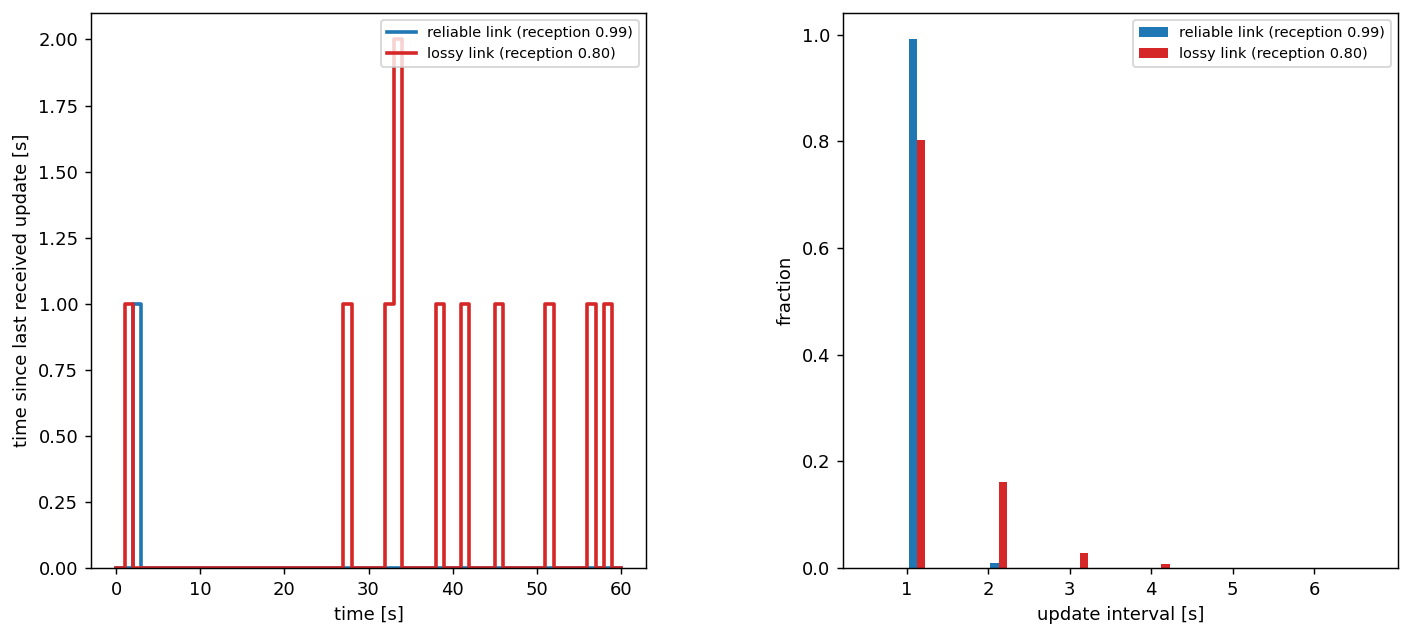

  reliable link (reception 0.99): mean update interval 1.009 s (interval / reception = 1.010), worst 2 s
     lossy link (reception 0.80): mean update interval 1.244 s (interval / reception = 1.250), worst 7 s


In [4]:
def update_ages(reception: float, seed: int, n_ticks: int = 4000):
    """Per-tick age of the held message, and the gaps between fresh arrivals."""
    comm = Comm(reception_prob={("SRC", "RCV"): reception}, latency=constant_latency(0.0))
    generator, state = comm_rng(seed), comm.initial_state()
    ages, arrivals, last = [], [], None
    for k in range(n_ticks):
        t = k * INTERVAL
        state = comm.step(state, [message("SRC", t)], LINK_ROSTER, t, generator)
        held = state.held.get(("RCV", "SRC"))
        if held is None:
            continue
        ages.append((t, t - held.t_meas))
        if held.t_meas != last:
            arrivals.append(t)
            last = held.t_meas
    return ages, np.diff(arrivals)


links = [("reliable link (reception 0.99)", 0.99, BLUE),
         ("lossy link (reception 0.80)", 0.80, RED)]
runs = {p: update_ages(p, 20260725 + i) for i, (_, p, _) in enumerate(links)}

fig, (a_age, a_int) = plt.subplots(1, 2, figsize=(12.0, 5.0))
for label, p, colour in links:
    ages, _ = runs[p]
    window = [(t, a) for t, a in ages if t <= 60.0]
    a_age.step([t for t, _ in window], [a for _, a in window], where="post",
               color=colour, lw=2.0, label=label)
a_age.set_xlabel("time [s]")
a_age.set_ylabel("time since last received update [s]")
a_age.set_ylim(bottom=0)
a_age.legend(fontsize=8, loc="upper right")
a_age.set_box_aspect(1)

vals = [runs[p][1] for _, p, _ in links]
a_int.hist(vals, bins=np.arange(0.5, 7.0, 0.25),
           weights=[np.full(v.size, 1.0 / v.size) for v in vals],
           color=[c for _, _, c in links], label=[lbl for lbl, _, _ in links])
a_int.set_xlabel("update interval [s]")
a_int.set_ylabel("fraction")
a_int.set_xticks(range(1, 7))
a_int.legend(fontsize=8, loc="upper right")
a_int.set_box_aspect(1)
fig.tight_layout()
plt.show()

for label, p, _ in links:
    ages, intervals = runs[p]
    print(f"{label:>32}: mean update interval {intervals.mean():.3f} s "
          f"(interval / reception = {INTERVAL / p:.3f}), worst {intervals.max():.0f} s")

## Latency

A delivered message still arrives late. `latency` is either a fixed number of seconds or a
`LatencyDistribution` — any callable taking a generator and returning a delay. Three shapes ship
with the model:

- `constant_latency(seconds)` — a fixed delay. It draws no randomness at all.
- `uniform_latency(low, high)` — the simple spread.
- `lognormal_latency(median, sigma)` — positive, right-skewed, a thin tail of late arrivals. It is
  parameterised by the **median** because `exp(mu)` *is* the median of a lognormal, which makes the
  typical delay directly readable.

Delivery is anchored to the measurement: a message measured at `t_meas` becomes available at
`t_meas + delay`, not at the tick it was offered. Because a delay can in principle exceed the
broadcast interval, a late old message could arrive after a newer one — the receiver always keeps
the message that is freshest by `t_meas`, so a straggler never overwrites a more recent fix.

The figure below pairs the delay distribution with what it does downstream. On the left is a
lognormal delay as an example shape. On the right is the **update interval** — the gap between two
consecutive *received* messages — with and without that delay. Without latency the interval is a
set of sharp spikes at whole multiples of the broadcast interval, one spike per number of
consecutive drops. Adding a sub-interval delay smears each spike but does not move it: at this
cadence a late message still lands before the next decision, so every *extra* interval is a dropped
message, not a slow one.

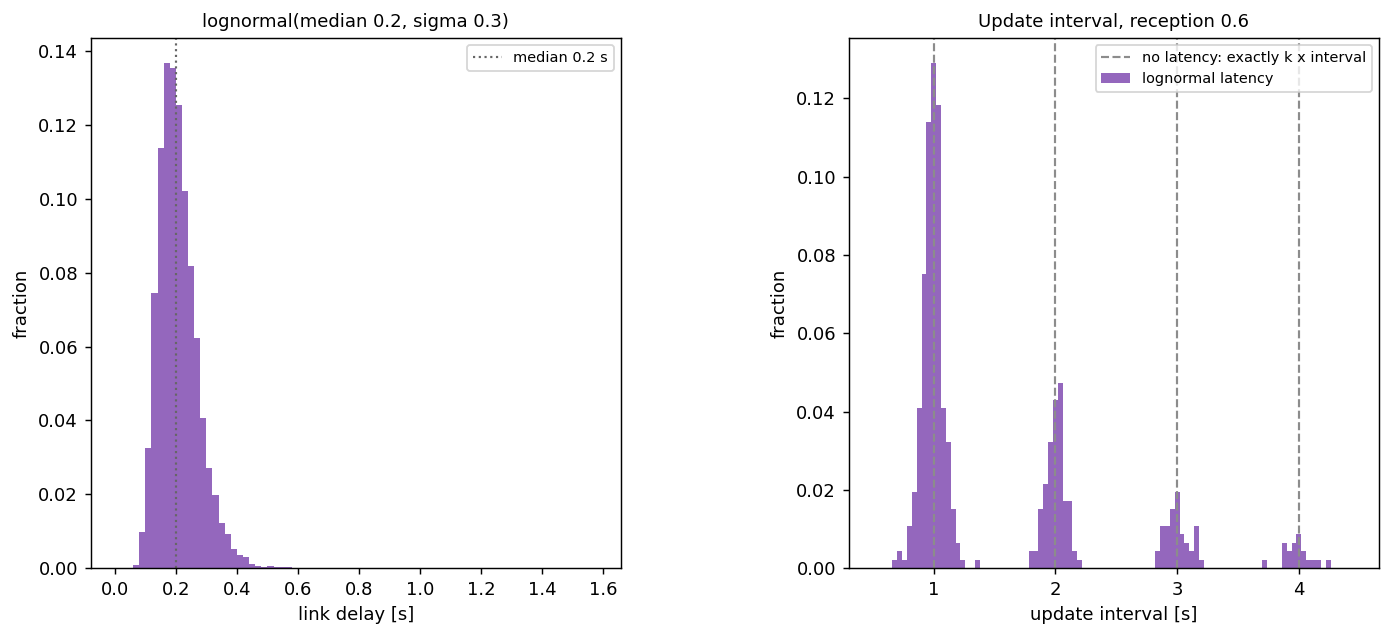

no latency:        mean update interval 1.664 s, std 1.069 s
lognormal latency: mean update interval 1.710 s, std 1.168 s
the median delay is 20% of a broadcast interval, and it moves the mean update interval by 0.046 s

a t_meas=1.0 message arriving after a t_meas=5.0 one -> receiver still holds t_meas 5.0 (gs 99.0)


In [5]:
RECEPTION = 0.6


def received_gaps(latency, reception=RECEPTION, seed=20260725, n_tx=800, poll=0.02):
    """Gaps between *consecutive received* messages on one link.

    Reception is sampled at a fine `poll` rather than at transmit times, so the sub-interval spread
    that latency adds is visible; timing it at transmit times would quantise it away.
    """
    comm = Comm(reception_prob={("SRC", "RCV"): reception}, latency=latency)
    generator, state = comm_rng(seed), comm.initial_state()
    tx_times = [k * INTERVAL for k in range(n_tx)]
    arrivals, last, ti, t = [], None, 0, 0.0
    while t <= tx_times[-1] + 1e-9:
        due = []
        while ti < len(tx_times) and tx_times[ti] <= t + 1e-9:
            due.append(message("SRC", tx_times[ti]))
            ti += 1
        state = comm.step(state, due, LINK_ROSTER, t, generator)
        held = state.held.get(("RCV", "SRC"))
        if held is not None and held.t_meas != last:
            arrivals.append(t)
            last = held.t_meas
        t += poll
    return np.diff(arrivals)


LOGNORMAL = lognormal_latency(0.2, 0.3)
fig, (a_dist, a_gap) = plt.subplots(1, 2, figsize=(12.0, 5.0))

# left: the delay distribution itself
generator = comm_rng(1)
draws = np.array([LOGNORMAL(generator) for _ in range(20000)])
a_dist.hist(draws, bins=np.arange(0.0, 1.6, 0.02), weights=np.full(draws.size, 1.0 / draws.size),
            color=PURPLE)
a_dist.axvline(0.2, color="0.4", ls=":", lw=1.2, label="median 0.2 s")
a_dist.set_xlabel("link delay [s]")
a_dist.set_ylabel("fraction")
a_dist.set_title("lognormal(median 0.2, sigma 0.3)", fontsize=10)
a_dist.legend(fontsize=8)
a_dist.set_box_aspect(1)

# right: what that delay does to the interval between consecutive received messages
sharp = received_gaps(constant_latency(0.0))
smeared = received_gaps(LOGNORMAL)
# without latency every gap is exactly k x interval, so it is drawn as reference lines rather than
# a histogram -- three spikes of height 0.9 would flatten the smeared distribution beside them
for k in range(1, 5):
    a_gap.axvline(k * INTERVAL, color=GREY, ls="--", lw=1.2,
                  label="no latency: exactly k x interval" if k == 1 else None)
a_gap.hist(smeared, bins=np.arange(0.5, 4.5, 0.04),
           weights=np.full(smeared.size, 1.0 / smeared.size), color=PURPLE,
           label="lognormal latency")
a_gap.set_xlabel("update interval [s]")
a_gap.set_ylabel("fraction")
a_gap.set_xticks(range(1, 5))
a_gap.set_title(f"Update interval, reception {RECEPTION}", fontsize=10)
a_gap.legend(fontsize=8)
a_gap.set_box_aspect(1)
fig.tight_layout()
plt.show()

print(f"no latency:        mean update interval {sharp.mean():.3f} s, std {sharp.std():.3f} s")
print(f"lognormal latency: mean update interval {smeared.mean():.3f} s, std {smeared.std():.3f} s")
print(f"the median delay is {0.2 / INTERVAL:.0%} of a broadcast interval, and it moves the mean "
      f"update interval by {abs(smeared.mean() - sharp.mean()):.3f} s")

# a straggler cannot overwrite a fresher fix
comm = Comm(reception_prob=1.0, latency=constant_latency(0.0))
state = comm.step(comm.initial_state(), [message("INT", 5.0, gs=99.0)], ROSTER, 5.0, comm_rng(0))
state = comm.step(state, [message("INT", 1.0, gs=11.0)], ROSTER, 5.0, comm_rng(0))
held = state.held[("OWN", "INT")]
print(f"\na t_meas=1.0 message arriving after a t_meas=5.0 one -> receiver still holds "
      f"t_meas {held.t_meas} (gs {held.state.gs})")

## Directed links

A broadcast is offered to each other aircraft independently, so reception is a property of the
**directed link**, not of the message. `reception_prob` accepts a mapping keyed
`(source, receiver)` — read "from → to" — and links absent from the mapping default to 1.0.

Two aircraft the same distance apart can sit in different interference, or carry different
antennas, so `OWN → INT` and `INT → OWN` are independent draws and one can land while the other
drops in the same tick. Because an absent key means "no loss", a mistyped identifier would silently
apply no loss at all; `validate_ids` is called at the composition root to catch that.

In [6]:
comm = Comm(reception_prob={("OWN", "INT"): 0.80,   # OWN's broadcasts often lost
                            ("INT", "OWN"): 0.99})  # INT's nearly always heard
generator, state = comm_rng(4), comm.initial_state()
landed = {("OWN", "INT"): 0, ("INT", "OWN"): 0}
n = 20000
for k in range(n):
    state = comm.step(CommState(), [message("OWN", float(k)), message("INT", float(k))],
                      ROSTER, float(k), generator)
    for (receiver, source) in state.held:
        landed[(source, receiver)] += 1

for link, count in landed.items():
    print(f"{link[0]} -> {link[1]}: {count / n:.3f} delivered")

try:
    Comm(reception_prob={("OWN", "TYPO"): 0.5}).validate_ids(frozenset(IDS))
except ValueError as exc:
    print("\nvalidate_ids:", str(exc).split(".")[0])

OWN -> INT: 0.800 delivered
INT -> OWN: 0.990 delivered

validate_ids: reception_prob names aircraft not in the fleet: ['TYPO']


## Radio failure

`reception_prob` drops an individual message and re-draws next tick, so it has no memory: a radio
that is *out* for a stretch of time cannot be expressed with it. That is what the `RadioHealth`
link gate adds. Each aircraft's transmitter and receiver fail independently at a rate in events per
second, so the mean time to failure is `1 / rate` whatever the broadcast cadence.

The two failures are mirror images. A down **transmitter** goes silent while still hearing
everyone; a down **receiver** goes blind while everyone still hears it. Either way the affected
receiver keeps holding what it last got, which is why an outage is not the same experiment as
`reception_prob = 0`.

`TransceiverComm` is the ready-made spelling of `Comm` plus one `RadioHealth` gate. Recovery rates
default to zero, which makes a failure permanent for the rest of the run.

Three aircraft are needed to tell the two failures apart. With only two, "AC1's transmitter died"
and "AC2's receiver died" sever the same single link and leave an identical state — a pairwise
encounter cannot distinguish them, so a study sweeping transmitter against receiver reliability
needs at least three.

AC1 sits on two links of different quality. Reading the key as "from → to", `("AC1", "AC2")` is the
link carrying AC1's broadcasts *to* AC2, so AC2's view of AC1 rides on it at reception 0.9, and
AC3's view of AC1 rides on `("AC1", "AC3")` at 0.5. The return links are set to match, so AC1's own
picture of AC2 is the good one and of AC3 the poor one.

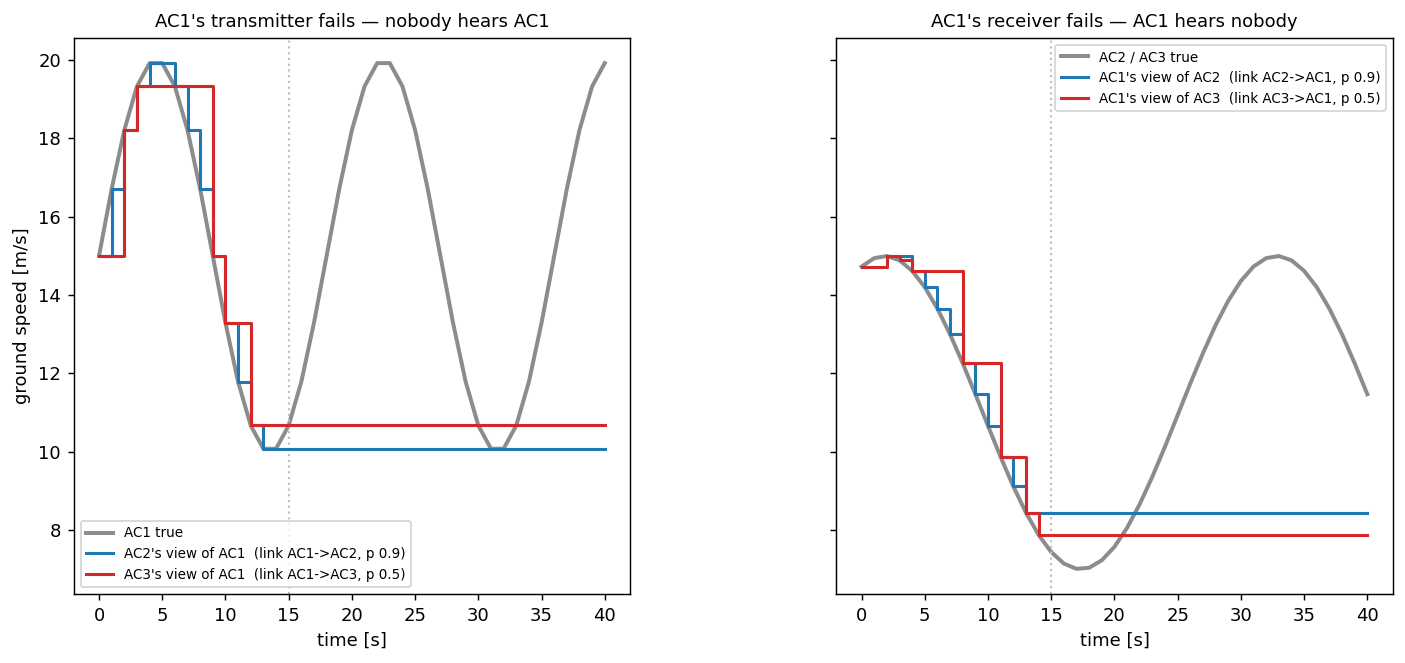

AC1's transmitter fails — nobody hears AC1
    AC2's view of AC1  (link AC1->AC2, p 0.9)    at 40 s: believes 10.08 m/s vs true 19.92 (error 9.85), held message is   26 s old
    AC3's view of AC1  (link AC1->AC3, p 0.5)    at 40 s: believes 10.67 m/s vs true 19.92 (error 9.25), held message is   28 s old
AC1's receiver fails — AC1 hears nobody
    AC1's view of AC2  (link AC2->AC1, p 0.9)    at 40 s: believes  8.44 m/s vs true 11.47 (error 3.02), held message is   27 s old
    AC1's view of AC3  (link AC3->AC1, p 0.5)    at 40 s: believes  7.88 m/s vs true 11.47 (error 3.59), held message is   26 s old


In [7]:
FLEET = ("AC1", "AC2", "AC3")
FLEET_ROSTER = tuple(aircraft(a) for a in FLEET)
T_FAIL, T_MAX = 15.0, 40.0
# "from -> to": AC1's broadcasts reach AC2 on a good link and AC3 on a poor one, and the return
# links match, so AC1's own picture of AC2 is the good one and of AC3 the poor one.
LINKS = {("AC1", "AC2"): 0.9, ("AC2", "AC1"): 0.9,
         ("AC1", "AC3"): 0.5, ("AC3", "AC1"): 0.5}


def gs_of(aid: str, t: float) -> float:
    """AC1 has its own speed profile; AC2 and AC3 share one, so each panel has a single truth.

    Both periods are chosen not to divide the 40 s window: a profile that repeats near the readout
    time would let a frozen belief coincide with the truth by accident and hide the very effect the
    figure is drawn to show.
    """
    if aid == "AC1":
        return 15.0 + 5.0 * math.sin(2.0 * math.pi * t / 18.0)
    return 11.0 + 4.0 * math.sin(2.0 * math.pi * t / 31.0 + 1.2)


def outage(subsystem: str):
    """AC1's transmitter or receiver fails at T_FAIL. Returns t and the four directed beliefs."""
    comm = TransceiverComm(reception_prob=LINKS)  # rates 0: we script the failure ourselves
    generator, state = comm_rng(11), comm.initial_state()
    rows = []
    t = 0.0
    while t <= T_MAX + 1e-9:
        if t >= T_FAIL:  # impose the outage on the gate's own state
            down = {f"{subsystem}_down": frozenset({"AC1"})}
            state = replace(state, gates=(replace(radio_health(state), **down),))
        state = comm.step(state, [message(a, t, gs_of(a, t)) for a in FLEET],
                          FLEET_ROSTER, t, generator)

        def believed(receiver: str, source: str) -> float:
            seen = LastKnown().perceived(state, receiver, source, t)
            return float("nan") if seen is None else seen.gs

        def staleness(receiver: str, source: str) -> float:
            a = age(state, receiver, source, t)
            return float("nan") if a is None else a

        rows.append((t, gs_of("AC1", t), gs_of("AC2", t),
                     believed("AC2", "AC1"), believed("AC3", "AC1"),   # others' view of AC1
                     believed("AC1", "AC2"), believed("AC1", "AC3"),   # AC1's view of others
                     staleness("AC2", "AC1"), staleness("AC3", "AC1"),
                     staleness("AC1", "AC2"), staleness("AC1", "AC3")))
        t += INTERVAL
    return np.array(rows)


# (subsystem, title, truth column of the observed aircraft,
#  [(belief col, age col, colour, label)])
panels = [
    ("tx", "AC1's transmitter fails — nobody hears AC1",
     1, [(3, 7, BLUE, "AC2's view of AC1  (link AC1->AC2, p 0.9)"),
         (4, 8, RED, "AC3's view of AC1  (link AC1->AC3, p 0.5)")]),
    ("rx", "AC1's receiver fails — AC1 hears nobody",
     2, [(5, 9, BLUE, "AC1's view of AC2  (link AC2->AC1, p 0.9)"),
         (6, 10, RED, "AC1's view of AC3  (link AC3->AC1, p 0.5)")]),
]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), sharey=True)
for ax, (subsystem, title, truth_col, series) in zip(axes, panels):
    d = outage(subsystem)
    truth_label = "AC1 true" if subsystem == "tx" else "AC2 / AC3 true"
    ax.plot(d[:, 0], d[:, truth_col], color=GREY, lw=2.2, label=truth_label, zorder=2)
    for col, _, colour, label in series:
        ax.step(d[:, 0], d[:, col], where="post", color=colour, lw=1.7, label=label, zorder=3)
    ax.axvline(T_FAIL, color="0.75", ls=":", lw=1.2)  # the failure; titles name it
    ax.set_xlabel("time [s]")
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect(1)
axes[0].set_ylabel("ground speed [m/s]")
axes[0].legend(fontsize=7.5, loc="lower left")
axes[1].legend(fontsize=7.5, loc="upper right")
fig.tight_layout()
plt.show()

for subsystem, title, truth_col, series in panels:
    d = outage(subsystem)
    print(title)
    for col, age_col, _, label in series:
        err = abs(d[-1, col] - d[-1, truth_col])
        print(f"    {label:<44} at {T_MAX:.0f} s: believes {d[-1, col]:5.2f} m/s vs true "
              f"{d[-1, truth_col]:5.2f} (error {err:4.2f}), held message is "
              f"{d[-1, age_col]:4.0f} s old")

## Surveillance range

Reception probability drops individual messages wherever the two aircraft happen to be. A
surveillance *range* is a different statement: beyond `max_range` metres the link does not exist,
so nothing is ever received, and at or inside it the link behaves normally.

`SurveillanceRange` is a **link gate** — the same seam `RadioHealth` uses. A gate answers one
question, "may this broadcast be offered on this directed link right now?", and a link is offered
only if every gate admits it. Range and radio failure therefore compose without either knowing
about the other.

Three things about the parameter are deliberate.

`max_range` is a **scalar** applied to every link, where `reception_prob` also accepts a per-link
mapping. That is a modelling claim: the range is an assumed *performance* of the surveillance
system every aircraft carries, so a different range per pair would be describing different
equipment on each link. It is normally read off a required minimum surveillance distance,
`d_surv_min` in the standards.

The comparison **admits at exactly `max_range`** (`d <= max_range`). A system required to see out
to `d_surv_min` is expected to work at that distance and to fail only beyond it.

Range is measured between **true** positions, not broadcast ones. Whether a link physically closes
is a fact about where the aircraft are; what each aircraft believes about the other is downstream
of the link, so letting navigation error decide whether a message is receivable would be circular.
This is why the channel is handed the roster as states rather than ids.

A gate is a **veto, not `reception_prob = 0`**. An out-of-range link consumes no reception draw at
all, so sweeping `max_range` changes which links close without shifting the random stream
underneath the links that stay open. Written as a zero probability it would spend one draw per
suppressed link and re-base every number after it. (A *soft* link budget, where reception falls off
smoothly with range, is the opposite case: the draw still happens, so it would belong in the
reception probability rather than in a gate.)

In [8]:
MAX_RANGE = 5000.0     # m -- the assumed surveillance performance
MISS = 500.0           # m -- how close INT passes OWN
CLOSING = 30.0         # m/s
T_MAX = 800.0

# OWN is parked; INT flies due east on a track offset MISS metres north of it, starting 12 km west.
OWN_STATE = aircraft("OWN", gs=0.0)
_track_lat, _track_lon = geo.forward(52.0, 4.0, 0.0, MISS)


def int_at(t: float):
    """INT after t seconds: 12 km west of the closest point, flying east at CLOSING."""
    lat, lon = geo.forward(_track_lat, _track_lon, 90.0, -12_000.0 + CLOSING * t)
    return AircraftState(id="INT", lat=lat, lon=lon, trk=90.0, gs=CLOSING)


def fly(max_range: float, reception: float = 1.0, seed: int = 0):
    """Step the pair past each other; per tick, the separation and OWN's belief about INT.

    Columns: t, separation [m], 1 if a fresh message from INT landed this tick, age of OWN's held
    message [s] (nan before first contact).
    """
    comm = Comm(reception_prob=reception, latency=0.0,
                gates=(SurveillanceRange(max_range=max_range),))
    generator, state, rows = comm_rng(seed), comm.initial_state(), []
    for k in range(int(T_MAX) + 1):
        t, intr = float(k), int_at(float(k))
        roster = (OWN_STATE, intr)
        state = comm.step(state, [Message("INT", intr, t)], roster, t, generator)
        held = state.held.get(("OWN", "INT"))
        _, separation = geo.qdrdist(OWN_STATE.lat, OWN_STATE.lon, intr.lat, intr.lon)
        rows.append((t, separation,
                     1.0 if held is not None and held.t_meas == t else 0.0,
                     float("nan") if held is None else t - held.t_meas))
    return np.array(rows)


d = fly(MAX_RANGE)
fresh = d[d[:, 2] == 1.0]
print(f"max_range {MAX_RANGE:.0f} m, reception 1.0, {len(d)} broadcasts offered")
print(f"  delivered on {len(fresh):.0f} ticks, from t={fresh[0, 0]:.0f}s to t={fresh[-1, 0]:.0f}s")
print(f"  separation at first and last delivery: {fresh[0, 1]:.1f} m, {fresh[-1, 1]:.1f} m")
print(f"  widest separation that ever delivered: {fresh[:, 1].max():.1f} m "
      f"(max_range is {MAX_RANGE:.0f} m)")
out = d[d[:, 2] == 0.0]
print(f"  closest separation that never delivered: {out[:, 1].min():.1f} m")

max_range 5000 m, reception 1.0, 801 broadcasts offered
  delivered on 331 ticks, from t=235s to t=565s
  separation at first and last delivery: 4975.2 m, 4975.2 m
  widest separation that ever delivered: 4975.2 m (max_range is 5000 m)
  closest separation that never delivered: 5005.0 m


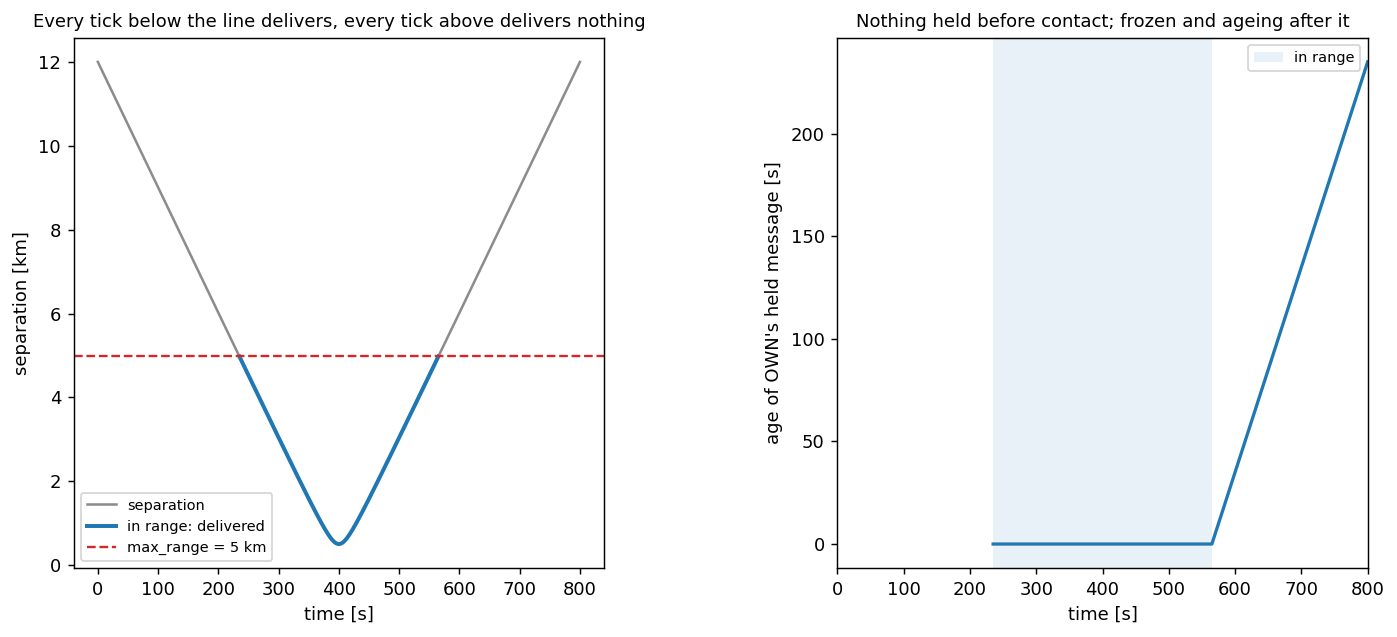

In [9]:
fig, (a_sep, a_age) = plt.subplots(1, 2, figsize=(12.0, 5.0))

# left: the separation history, with the ticks that actually delivered marked on it
inside = d[:, 1] <= MAX_RANGE
a_sep.plot(d[:, 0], d[:, 1] / 1000.0, color=GREY, lw=1.4, label="separation")
a_sep.plot(d[inside, 0], d[inside, 1] / 1000.0, color=BLUE, lw=2.2, label="in range: delivered")
a_sep.axhline(MAX_RANGE / 1000.0, color=RED, ls="--", lw=1.3,
              label=f"max_range = {MAX_RANGE / 1000.0:.0f} km")
a_sep.set_xlabel("time [s]")
a_sep.set_ylabel("separation [km]")
a_sep.set_title("Every tick below the line delivers, every tick above delivers nothing",
                fontsize=10)
a_sep.legend(fontsize=8)
a_sep.set_box_aspect(1)

# right: what that does to OWN's picture of INT -- the quantity a decision actually consumes
a_age.plot(d[:, 0], d[:, 3], color=BLUE, lw=1.8)
a_age.axvspan(d[inside, 0].min(), d[inside, 0].max(), color=BLUE, alpha=0.10, lw=0,
              label="in range")
a_age.set_xlim(0.0, T_MAX)  # the same span as the left panel, so the gap before contact shows
a_age.set_xlabel("time [s]")
a_age.set_ylabel("age of OWN's held message [s]")
a_age.set_title("Nothing held before contact; frozen and ageing after it", fontsize=10)
a_age.legend(fontsize=8)
a_age.set_box_aspect(1)
fig.tight_layout()
plt.show()

The left panel is the gate itself: the switch happens exactly where the separation crosses
`max_range`, in both directions, with no transition region. The right panel is why it matters —
before first contact OWN holds nothing at all and flies nominal, and once INT passes back out of
range OWN keeps its **last** message and goes on deciding against a belief that gets one second
staler every second. That is the same hold-as-is behaviour a radio outage produces, and it is not
the same experiment as switching the link off, which would leave OWN with no traffic at all.

The two effects compose, and the composition is one-sided: reception probability thins out the
deliveries inside the range and does nothing outside it, where there is nothing left to thin.

In [10]:
for reception in (1.0, 0.9, 0.5):
    run = fly(MAX_RANGE, reception=reception, seed=4)
    inside_ticks = run[run[:, 1] <= MAX_RANGE]
    outside_ticks = run[run[:, 1] > MAX_RANGE]
    print(f"reception {reception:.1f}: delivered on {inside_ticks[:, 2].sum():3.0f} of "
          f"{len(inside_ticks)} in-range ticks, {outside_ticks[:, 2].sum():.0f} of "
          f"{len(outside_ticks)} out-of-range ticks")

reception 1.0: delivered on 331 of 331 in-range ticks, 0 of 470 out-of-range ticks
reception 0.9: delivered on 285 of 331 in-range ticks, 0 of 470 out-of-range ticks
reception 0.5: delivered on 144 of 331 in-range ticks, 0 of 470 out-of-range ticks


### Three aircraft: the range is per link, and it is not transitive

Two aircraft can only be in range or out of it, so a pair cannot show what a *range* does to a
fleet's picture of itself. Three can. Below, AC2 sits still while AC1 closes from the west and AC3
from the east at a different speed, so all three pairwise separations differ at every instant and
cross `max_range` at three different times.

That produces a middle regime with no two-aircraft equivalent: AC2 is in contact with both
neighbours while AC1 and AC3, further apart from each other than either is from AC2, hear nothing
from one another at all. Range closes **links**, not aircraft, and being in range is not something
that passes along a chain — the channel does not relay.

In [11]:
AC2_STATE = aircraft("AC2", gs=0.0)  # parked at the origin; the other two converge on it


def trio_at(t: float):
    """The three true states at time t. AC1 approaches from the west at 10 m/s, AC3 from the east
    at 5 m/s, from different starting distances -- so no two pairwise separations ever coincide."""
    west = 8000.0 - 10.0 * t   # AC1 -- AC2 separation
    east = 6000.0 - 5.0 * t    # AC2 -- AC3 separation
    lat1, lon1 = geo.forward(AC2_STATE.lat, AC2_STATE.lon, 270.0, west)
    lat3, lon3 = geo.forward(AC2_STATE.lat, AC2_STATE.lon, 90.0, east)
    return (AircraftState(id="AC1", lat=lat1, lon=lon1, trk=90.0, gs=10.0),
            AC2_STATE,
            AircraftState(id="AC3", lat=lat3, lon=lon3, trk=270.0, gs=5.0))


PAIRS = (("AC1", "AC2"), ("AC2", "AC3"), ("AC1", "AC3"))
T_TRIO = 700.0


def fly_trio(max_range: float, seed: int = 0):
    """Step all three past each other. Returns (times, separation per pair, contact per pair),
    where contact is 1.0 on the ticks that pair actually exchanged a fresh message both ways."""
    comm = Comm(reception_prob=1.0, latency=0.0,
                gates=(SurveillanceRange(max_range=max_range),))
    generator, state = comm_rng(seed), comm.initial_state()
    times, separation = [], {p: [] for p in PAIRS}
    contact = {p: [] for p in PAIRS}
    for k in range(int(T_TRIO) + 1):
        t, roster = float(k), trio_at(float(k))
        by_id = {s.id: s for s in roster}
        state = comm.step(state, [Message(s.id, s, t) for s in roster], roster, t, generator)
        times.append(t)
        for a, b in PAIRS:
            _, d = geo.qdrdist(by_id[a].lat, by_id[a].lon, by_id[b].lat, by_id[b].lon)
            separation[(a, b)].append(d)
            fresh = [state.held.get((rcv, src)) for rcv, src in ((a, b), (b, a))]
            contact[(a, b)].append(
                1.0 if all(m is not None and m.t_meas == t for m in fresh) else 0.0
            )
    return (np.array(times),
            {p: np.array(v) for p, v in separation.items()},
            {p: np.array(v) for p, v in contact.items()})


ts, sep, con = fly_trio(MAX_RANGE)
print(f"max_range {MAX_RANGE:.0f} m")
for pair in PAIRS:
    live = ts[con[pair] == 1.0]
    print(f"  {pair[0]}<->{pair[1]}: in contact from t={live[0]:.0f}s "
          f"({sep[pair][con[pair] == 1.0][0]:.0f} m) onwards, {len(live):.0f} of {len(ts)} ticks")

WATCH = 450.0  # inside the middle regime
i = int(WATCH)
print(f"\nat t={WATCH:.0f}s the three separations are all different:")
for pair in PAIRS:
    verdict = "in contact" if con[pair][i] else "hears nothing"
    print(f"  {pair[0]}<->{pair[1]}: {sep[pair][i]:6.0f} m -> {verdict}")

max_range 5000 m
  AC1<->AC2: in contact from t=301s (4990 m) onwards, 400 of 701 ticks
  AC2<->AC3: in contact from t=201s (4995 m) onwards, 500 of 701 ticks
  AC1<->AC3: in contact from t=601s (4985 m) onwards, 100 of 701 ticks

at t=450s the three separations are all different:
  AC1<->AC2:   3500 m -> in contact
  AC2<->AC3:   3750 m -> in contact
  AC1<->AC3:   7250 m -> hears nothing


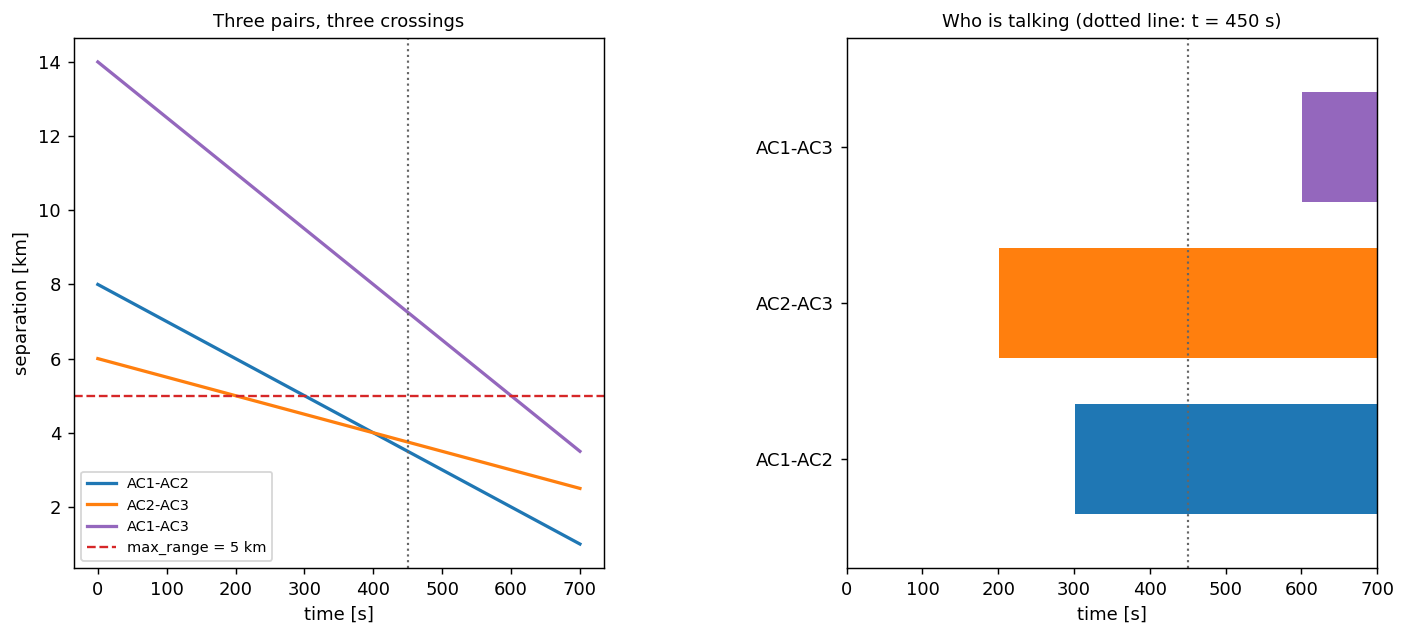

In [12]:
fig, (a_sep, a_con) = plt.subplots(1, 2, figsize=(12.0, 5.0))
colours = {("AC1", "AC2"): BLUE, ("AC2", "AC3"): ORANGE, ("AC1", "AC3"): PURPLE}

# left: the three pairwise separations, each crossing max_range at its own moment
for pair in PAIRS:
    a_sep.plot(ts, sep[pair] / 1000.0, color=colours[pair], lw=1.8,
               label=f"{pair[0]}-{pair[1]}")
a_sep.axhline(MAX_RANGE / 1000.0, color=RED, ls="--", lw=1.3,
              label=f"max_range = {MAX_RANGE / 1000.0:.0f} km")
a_sep.axvline(WATCH, color="0.4", ls=":", lw=1.2)
a_sep.set_xlabel("time [s]")
a_sep.set_ylabel("separation [km]")
a_sep.set_title("Three pairs, three crossings", fontsize=10)
a_sep.legend(fontsize=8)
a_sep.set_box_aspect(1)

# right: which pairs are actually talking -- one row per pair, filled where a message got through
for row, pair in enumerate(PAIRS):
    live = con[pair] == 1.0
    a_con.fill_between(ts, row - 0.35, row + 0.35, where=live, color=colours[pair], lw=0)
a_con.axvline(WATCH, color="0.4", ls=":", lw=1.2)
a_con.set_yticks(range(len(PAIRS)), [f"{a}-{b}" for a, b in PAIRS])
a_con.set_ylim(-0.7, len(PAIRS) - 0.3)
a_con.set_xlim(0.0, T_TRIO)
a_con.set_xlabel("time [s]")
a_con.set_title(f"Who is talking (dotted line: t = {WATCH:.0f} s)", fontsize=10)
a_con.set_box_aspect(1)
fig.tight_layout()
plt.show()

Read the right panel down the dotted line. AC2 is talking to both of its neighbours, and AC1 and
AC3 — the two furthest apart — are not talking to each other. Neither of them is out of touch with
the fleet, and neither is malfunctioning; the single link between them is simply longer than the
range. A fourth regime opens later, when the outer pair finally closes to within `max_range` and
all three links are up.

This is the same reason the radio-failure section needs three aircraft: at n = 2 there is one
undirected pair, so every effect either applies or does not, and the *structure* an effect imposes
on the fleet's picture of itself is invisible. A study of surveillance range should be run at n ≥ 3
for that reason — the pairwise reduction will report the range faithfully and tell you nothing
about the connectivity it produces.

## Reproducibility

Every draw comes from an explicit generator, and the layers take separate substreams: navigation
draws from one, the channel from another, transmit jitter from a third. Keeping them separate means
switching on a communication model cannot shift the navigation noise underneath it, so two runs
differing in one setting differ only because of that setting.

The draw order inside a tick is fixed as well: gates evolve first, then reception is drawn per
link, then latency only for messages that were received. A dropped message therefore costs one
draw and a delivered one costs two.

In [13]:
def run_once(seed: int, reception: float = 0.7):
    comm = Comm(reception_prob=reception, latency=lognormal_latency(0.2, 0.4))
    generator, state = comm_rng(seed), comm.initial_state()
    for k in range(50):
        state = comm.step(state, [message("OWN", float(k)), message("INT", float(k))],
                          ROSTER, float(k), generator)
    return {k: v.t_meas for k, v in state.held.items()}


print("same seed twice: ", run_once(5) == run_once(5))
print("different seed:  ", run_once(5) == run_once(6))

same seed twice:  True
different seed:   False


# Extending the channel

Four extension points, in order of how much you have to write. The first two are configuration; the
third adds an effect to the standard channel; the fourth replaces the channel entirely.

## Your own broadcast rate

The cadence is a `BroadcastSchedule`, and both runners take one. Pass `interval` in seconds or use
`at_rate` in hertz, and add `phase` or `jitter` when you want the fleet unsynchronised. A non-zero
`jitter` needs its own generator, because a dithered gap is a random draw.

From a configuration file the same three knobs are `broadcast_interval`, `broadcast_jitter` and
`broadcast_random_phase` under `simulation`.

In [14]:
from opencdarr.cd import StateBased
from opencdarr.cr import MVP
from opencdarr.crr import PastCPA
from opencdarr.fleet import Agent, run_fleet
from opencdarr.performance import M600
from opencdarr.scenario import create_conflict

own = AircraftState(id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0, pos_ci95=10.0, vel_ci95=1.0)
intr = create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=0.0, tlos=90.0, rpz=50.0)
agents = [Agent(own, M600), Agent(intr, M600)]
cdr = dict(rpz=50.0, t_lookahead=120.0, dt=0.2, detector=StateBased(),
           resolver=MVP(margin=1.05), recovery=PastCPA(bouncing_guard=True))
results = {}

for label, schedule in [
    ("1 Hz, aligned", BroadcastSchedule(interval=1.0)),
    ("2 Hz", BroadcastSchedule.at_rate(2.0)),
    ("0.5 Hz", BroadcastSchedule.at_rate(0.5)),
    ("1 Hz + jitter 0.2 s", BroadcastSchedule(interval=1.0, jitter=0.2)),
]:
    out = run_fleet(agents, navigation=GnssNavigation(), rng=comm_rng(2),
                    schedule=schedule, broadcast_rng=comm_rng(3), **cdr)
    results[label] = out.min_sep
    print(f"{label:>22}: min separation {out.min_sep:6.1f} m")

slower, base = results["0.5 Hz"], results["1 Hz, aligned"]
print(f"\nHalving the rate to 0.5 Hz costs {base - slower:.0f} m of separation "
      f"({100 * (base - slower) / base:.0f}% of the 1 Hz result): the resolver acts on a picture "
      f"that is on average twice as old.")

         1 Hz, aligned: min separation  356.1 m
                  2 Hz: min separation  404.1 m
                0.5 Hz: min separation  157.8 m
   1 Hz + jitter 0.2 s: min separation  404.9 m

Halving the rate to 0.5 Hz costs 198 m of separation (56% of the 1 Hz result): the resolver acts on a picture that is on average twice as old.


## Your own latency model

A `LatencyDistribution` is any callable taking a generator and returning a delay in seconds. There
is no base class to inherit and nothing to register — a plain function or a lambda is enough.

The one rule is to draw from the generator you are handed rather than from a global source, so the
run stays reproducible from its seed.

In [15]:
def bimodal_latency(fast: float, slow: float, p_slow: float):
    """Most messages arrive quickly; a fraction take a retransmission and arrive much later."""
    def draw(generator) -> float:
        return slow if generator.random() < p_slow else fast
    return draw


comm = Comm(reception_prob=1.0, latency=bimodal_latency(0.05, 1.2, p_slow=0.15))
generator = comm_rng(9)
delays = [comm.latency(generator) for _ in range(5000)]
print(f"bimodal: {np.mean(np.array(delays) > 1.0):.1%} of messages take the slow path, "
      f"mean delay {np.mean(delays):.3f} s")

bimodal: 14.2% of messages take the slow path, mean delay 0.213 s


## Your own link gate

A `LinkGate` adds one effect to the standard channel. It answers a single question — may this
broadcast be offered on this directed link right now — and carries whatever state it needs to
answer it. Gates compose: a link is offered only if every gate admits it, so a radio failure and a
transmit duty cycle are two gates rather than a new class for the combination.

Three methods: `initial` returns the gate's starting state, `evolve` advances that state once per
step, and `admits` decides one link. Note that a veto costs no randomness — `admits` is consulted
ahead of the reception draw — so a gate cannot be written as a zero probability. An effect that
*modulates* the probability leaves the draw in place and belongs in `reception_prob` instead.

Implement it as a frozen dataclass so the experiment cache can key on it by value.

In [16]:
@dataclass(frozen=True)
class DutyCycle(LinkGate):
    """A transmitter that is only on for part of each period — a coarse channel-sharing model."""

    period: float = 4.0
    on_time: float = 1.0

    def initial(self) -> float:
        return 0.0  # seconds elapsed since the run began

    def evolve(self, own, receivers, elapsed: float, rng) -> float:
        return own + elapsed  # draws nothing: this gate is deterministic

    def admits(self, own, source: str, receiver: str) -> bool:
        return (own % self.period) < self.on_time


# one gate on its own
comm = Comm(reception_prob=1.0, gates=(DutyCycle(period=4.0, on_time=1.0),))
state, generator, offered = comm.initial_state(), comm_rng(0), []
for k in range(12):
    t = float(k)
    state = comm.step(state, [message("INT", t)], ROSTER, t, generator)
    held = state.held.get(("OWN", "INT"))
    offered.append("on " if held is not None and held.t_meas == t else "off")
print("duty cycle 1 s on / 4 s period:", " ".join(offered))

# two gates composed -- impossible to express as a single subclass
both = Comm(reception_prob=1.0, gates=(RadioHealth(rx_fail_rate=180.0), DutyCycle()))
state = both.initial_state()
names = [f"{type(g).__name__}(gate {i})" for i, g in enumerate(state.gates)]
print("\ntwo gates, two independent states threaded side by side:", names)
print("a link is offered only if both admit it")

duty cycle 1 s on / 4 s period: on  off off off on  off off off on  off off off

two gates, two independent states threaded side by side: ['RadioHealthState(gate 0)', 'float(gate 1)']
a link is offered only if both admit it


## Your own channel

When the effect is not a veto on top of Bernoulli reception — a queue, a retransmission protocol, a
bandwidth budget shared across the fleet — replace the channel itself. Subclass
`CommunicationModel` and implement `step`, plus `initial_state` if the model needs memory of its
own.

`step` must be pure: thread the state in and return a new one rather than mutating, so a cloned run
can never write through to its parent. Returning your own `CommState` subclass from `initial_state`
is what puts that memory in place before the first tick.

In [17]:
@dataclass(frozen=True)
class TokenState(CommState):
    """A CommState carrying this model's own memory: tokens left in the current second."""

    tokens: int = 0


class TokenBucket(CommunicationModel):
    """A shared bandwidth budget: at most `capacity` messages are delivered fleet-wide per tick."""

    def __init__(self, capacity: int = 1) -> None:
        self.capacity = capacity

    def initial_state(self) -> TokenState:
        return TokenState(tokens=self.capacity)

    def step(self, state, broadcasts, receivers, t, rng) -> TokenState:
        # `receivers` is the roster as *states*, not ids -- the channel is handed the aircraft so
        # that a geometry-dependent effect can read their positions. This model only needs `.id`.
        budget, held = self.capacity, dict(state.held)
        for msg in broadcasts:
            for receiver in (r.id for r in receivers):
                if receiver == msg.source or budget == 0:
                    continue
                held[(receiver, msg.source)] = msg
                budget -= 1
        return TokenState(held=held, tokens=budget)


comm = TokenBucket(capacity=1)
state = comm.initial_state()
state = comm.step(state, [message("OWN", 0.0), message("INT", 0.0)], ROSTER, 0.0, comm_rng(0))
print(f"capacity 1: {len(state.held)} of 2 offered links delivered -> {sorted(state.held)}")
print(f"tokens left: {state.tokens}")

# it drops straight into the stack like any other model
cns = CNS(communication=TokenBucket(capacity=1), surveillance=LastKnown())
cns_state = cns.initial_state(2)
cns_state, perception = cns.sense([aircraft("OWN"), aircraft("INT")], (0, 1), 0.0,
                                  cns_state, CnsStreams(comm=comm_rng(0)))
for i, aid in enumerate(IDS):
    note = "  <- the budget went to the other link this tick" if not perception[i].traffic else ""
    print(f"through CNS.sense, {aid} sees {[ac.id for ac in perception[i].traffic]}{note}")

capacity 1: 1 of 2 offered links delivered -> [('INT', 'OWN')]
tokens left: 0
through CNS.sense, OWN sees []  <- the budget went to the other link this tick
through CNS.sense, INT sees ['OWN']


## What connects to this

Navigation produces the measurement this layer carries, and surveillance decides what the receiver
does with a stale one — the two pages either side of this one. The effects here are what make a
fleet's perception asymmetric: two aircraft the same distance apart can hold very different
pictures of each other, and that is what the separation logic downstream has to stay correct under.

For a study that varies transmitter against receiver reliability, note that a pairwise encounter
cannot separate them: at two aircraft both failures sever the same single link. That distinction
only becomes visible at three or more.